# Rap1 Binding Site Classifier

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from nn import io, nn, preprocess

- Use the read_text_file function from io.py to read in the 137 positive Rap1 motif examples.
- Use the read_fasta_file function from io.py to read in all the negative examples. Note that these sequences are much longer than the positive sequences, so you will need to process them to the same length.

In [2]:
POSITIVES_PATH = 'data/rap1-lieb-positives.txt'  
NEGATIVES_PATH = 'data/yeast-upstream-1k-negative.fa'

positives = io.read_text_file(POSITIVES_PATH)
negatives_long = io.read_fasta_file(NEGATIVES_PATH)
print('Data Loaded!')

Data Loaded!


In [3]:
pos_lens = [len(s) for s in positives]
seq_len = int(np.median(pos_lens))
print('Target sequence length:', seq_len)

# Produce negative candidates of same length as positive
negatives_processed = []
rng = np.random.default_rng(123)
for long_seq in negatives_long:
    if len(long_seq) < seq_len:
        continue
    max_windows = max(1, min(5, (len(long_seq) - seq_len + 1)))
    for _ in range(max_windows):
        start = rng.integers(0, len(long_seq) - seq_len + 1)
        negatives_processed.append(long_seq[start:start+seq_len])

print('Produced', len(negatives_processed), 'negative processed sequences of length', seq_len)

Target sequence length: 17
Produced 15815 negative processed sequences of length 17


- Balance your classes using your sample_seq function and explain why you chose the sampling scheme you did.

In [4]:
# Combine initial dataset
all_seqs = positives + negatives_processed
all_labels = [True] * len(positives) + [False] * len(negatives_processed)
print('Raw dataset size:', len(all_seqs), '; pos:', sum(all_labels), '; neg:', len(all_seqs)-sum(all_labels))

# Balance classes
sampled_seqs, sampled_labels = preprocess.sample_seqs(all_seqs, all_labels)
print('Sampled dataset size:', len(sampled_seqs), '; pos:', sum(sampled_labels), '; neg:', len(sampled_seqs)-sum(sampled_labels))

Raw dataset size: 15952 ; pos: 137 ; neg: 15815
Sampled dataset size: 31630 ; pos: 15815 ; neg: 15815


- One-hot encode the data using your one_hot_encode_seqs function.
- Split the data into training and validation sets.

In [5]:
# One-hot encode
X = preprocess.one_hot_encode_seqs(sampled_seqs)
y = np.array(sampled_labels, dtype=float).reshape(-1,1)
print('Encoded X shape:', X.shape, '; y shape:', y.shape)

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, y_train.shape, '; Val:', X_val.shape, y_val.shape)

Encoded X shape: (31630, 68) ; y shape: (31630, 1)
Train: (25304, 68) (25304, 1) ; Val: (6326, 68) (6326, 1)


- Generate an instance of your NeuralNetwork class with an appropriate architecture.

In [6]:
input_dim = X.shape[1]
arch = [
    {'input_dim': input_dim, 'output_dim': 256, 'activation': 'relu'},
    {'input_dim': 256, 'output_dim': 64, 'activation': 'relu'},
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 1, 'activation': 'sigmoid'}
]

# Hyperparameters
lr = 0.01
seed = 123
batch_size = 32
epochs = 40
loss_function = 'binary_cross_entropy'

model = nn.NeuralNetwork(nn_arch=arch, lr=lr, seed=seed, batch_size=batch_size, epochs=epochs, loss_function=loss_function)
print('Model created!')

Model created!


- Train your neural network on the training data.

In [7]:
train_losses, val_losses = model.fit(X_train, y_train, X_val, y_val)

- Plot your training and validation loss by epoch.

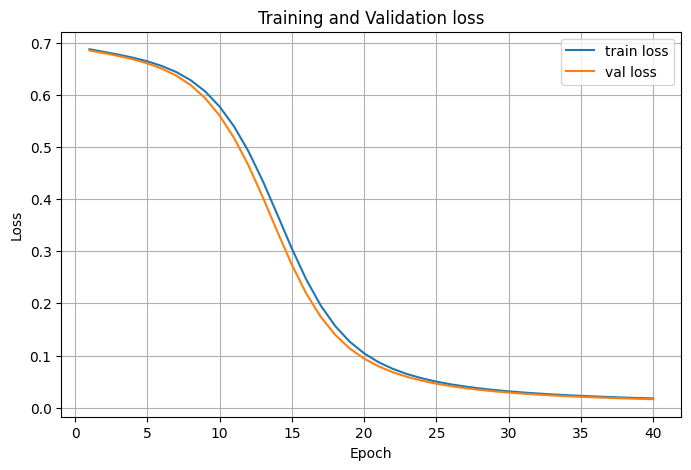

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='train loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation loss')
plt.legend()
plt.grid(True)
plt.show()

- Report the accuracy of your classifier on your validation dataset.
- Explain your choice of loss function and hyperparameters.

In [9]:
# Predict on validation set
y_val_hat = model.predict(X_val).reshape(-1)
# Compute accuracy at 0.5 threshold
y_true = y_val.reshape(-1)
y_pred = (y_val_hat >= 0.5).astype(int)
acc = accuracy_score(y_true, y_pred)
try:
    auc = roc_auc_score(y_true, y_val_hat)
except Exception:
    auc = float('nan')
print(f'Validation accuracy: {acc:.4f}')
print(f'Validation ROC-AUC: {auc:.4f}')

Validation accuracy: 0.9983
Validation ROC-AUC: 1.0000


## Explanation of Loss Function and Hyperparameters

**Loss function**: 
- I used binary cross-entropy (log loss) since it is the standard loss for binary classification and is appropriate for probabilistic outputs from a sigmoid. It also directly optimizes the likelihood of correct labels.

**Hyperparameters**:
- Learning rate = 0.01: a moderate value to allow stable learning since this is a relatively shallow MLP.
- Batch size = 32: seems like a reasonable minibatch size for stable gradient estimates.
- Epochs = 40: was sufficient to observe convergence.